## Neural Networks for Binary Classification & IMDB Dataset

A Neural Network for Binary Classification is a model designed to predict one of two possible outcomes (e.g., positive vs negative). It typically consists of an input layer, one or more hidden layers with activation functions like ReLU, and an output layer with a sigmoid activation that produces a probability between 0 and 1. The model is trained using binary cross-entropy loss, which measures how well the predicted probabilities match the true labels.

The IMDB Dataset is a widely used benchmark for binary classification in natural language processing. It contains 50,000 movie reviews labeled as positive or negative. Each review is preprocessed into sequences of integers representing words. The goal is to train a neural network to classify the sentiment of a review based on its text.

When applied to the IMDB dataset, neural networks learn patterns in word usage and context to determine sentiment. Despite its simplicity, this task demonstrates key deep learning concepts such as text vectorization, overfitting control (e.g., validation sets, dropout), and performance evaluation using accuracy.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb

# Load the top 10,000 most frequent words
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

print("Train Size:", x_train.shape)
print("Test Size:", x_test.shape)
print("First samples:", len(x_train[0]), "; Label:", y_train[0])

Train Size: (25000,)
Test Size: (25000,)
First samples: 218 ; Label: 1


In [ ]:
import numpy as np

# Apply Multi-Hot Encoding
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0

    return results

# Apply to the dataset
x_train = vectorize_sequences(x_train, 10000)
x_test = vectorize_sequences(x_test, 10000)

y_train = np.asarray(y_train).astype('float32')
y_test = np.asarray(y_train).astype('float32')

# Final shape
print('Shape x_train:', x_train.shape)
print('Shape x_test :', x_test.shape)

Shape x_train: (25000, 10000)
Shape x_test : (25000, 10000)


In [ ]:
# Create Validation Set
x_val = x_train[:8000]
partial_x_train = x_train[8000:]

y_val = y_train[:8000]
partial_y_train = y_train[8000:]

print("Shape x_val:", x_val.shape)
print("Shape partial_x_train:", partial_x_train.shape)
print("Shape y_val:", y_val.shape)
print("Shape partial_y_train:", partial_y_train.shape)

Shape x_val: (8000, 10000)
Shape partial_x_train: (17000, 10000)
Shape y_val: (8000,)
Shape partial_y_train: (17000,)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Training the model
hidden_layer1 = layers.Dense(16, activation='relu')
hidden_layer2 = layers.Dense(16, activation='relu')
output_layer = layers.Dense(1, activation='sigmoid')

imdb_model = keras.Sequential([hidden_layer1, hidden_layer2, output_layer])

# Compile
imdb_model.compile(optimizer='rmsprop',
                   loss='binary_crossentropy', metrics=['accuracy'])


# Fit the model
history_imdb = imdb_model.fit(partial_x_train, partial_y_train,
                              epochs=20, batch_size=256,
                              validation_data=(x_val, y_val),
                              verbose=1)

# Save it, useful for visualization
history = history_imdb.history

Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8152 - loss: 0.4706 - val_accuracy: 0.8808 - val_loss: 0.3284
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9101 - loss: 0.2577 - val_accuracy: 0.8920 - val_loss: 0.2763
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9328 - loss: 0.1897 - val_accuracy: 0.8752 - val_loss: 0.3137
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9470 - loss: 0.1517 - val_accuracy: 0.8898 - val_loss: 0.2879
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9604 - loss: 0.1228 - val_accuracy: 0.8861 - val_loss: 0.3081
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9683 - loss: 0.0983 - val_accuracy: 0.8836 - val_loss: 0.3355
Epoch 7/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9758 - loss: 0.0804 - val_accuracy: 0.8829 - val_loss: 0.3644
Epoch 8/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9822 - loss: 0.0637 - val_accuracy: 0.8775 - v

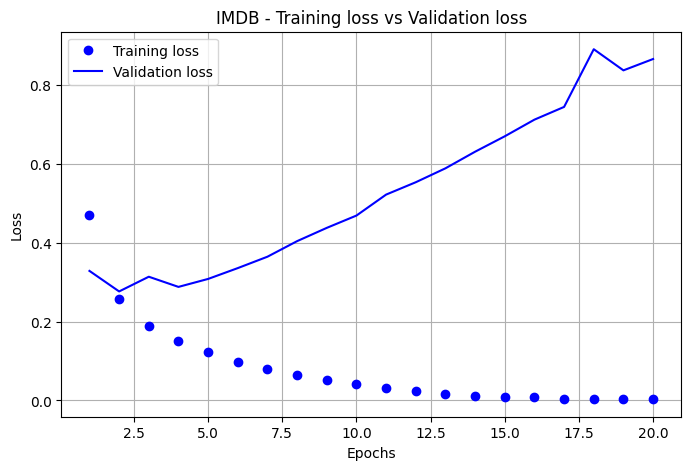

In [ ]:
import matplotlib.pyplot as plt

# Take loss values from history
loss_values = history['loss']
val_loss_values = history['val_loss']

# create variables
epochs = range(1, len(loss_values) + 1)

# Plotting Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('IMDB - Training loss vs Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Neural Networks for Multi-Class Classification & Reuters Dataset

A Neural Network for Multi-Class Classification is designed to classify inputs into more than two categories. The architecture is similar to binary classification, but the output layer uses a softmax activation function to produce a probability distribution over all classes. The model is typically trained using categorical cross-entropy loss, which evaluates how well the predicted class probabilities match the true labels.

The Reuters Dataset is a standard benchmark for multi-class classification tasks in natural language processing. It contains newswire articles categorized into 46 different topics such as politics, economics, and sports. Each article is preprocessed into sequences of integers representing words, allowing neural networks to learn from textual data.

When applied to the Reuters dataset, neural networks learn to distinguish between multiple topics by capturing patterns in word frequency and context. This task highlights important deep learning concepts such as handling multiple classes, encoding labels (e.g., one-hot encoding), and evaluating performance using accuracy and class-wise metrics.

In [ ]:
from tensorflow.keras.datasets import reuters
import numpy as np

# Load the Reuters dataset (keep the 10,000 frequent words just like the IMDB)
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=10000)

# Display the sizes and number of unique labels
print("Train Size:", x_train.shape)
print("Test Size:", x_test.shape)
print("Unique labels:", len(np.unique(y_train)))

# Display the first sample
print("First samples:", len(x_train[0]), "; Label:", y_train[0])

Train Size: (8982,)
Test Size: (2246,)
Unique labels: 46
First samples: 87 ; Label: 3


In [ ]:
# Vectorize the sequence (same with the IMDB)
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0

    return results

# One-Hot encoding for the labels
def to_one_hot(labels, dimension=46):
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
        results[i, label] = 1.0
    return results

# Apply to the dataset
x_train = vectorize_sequences(x_train, 10000)
x_test = vectorize_sequences(x_test, 10000)

y_train = to_one_hot(y_train, 46)
y_test = to_one_hot(y_test, 46)

print('Shape x_train:', x_train.shape)
print('Shape x_test :', x_test.shape)
print('Shape y_train:', y_train.shape)
print('Shape y_test :', y_test.shape)

Shape x_train: (8982, 10000)
Shape x_test : (2246, 10000)
Shape y_train: (8982, 46)
Shape y_test : (2246, 46)


In [ ]:
# Validation set for the training process
x_val_reuters = x_train[:1000]
partial_x_train_reuters = x_train[1000:]
y_val_reuters = y_train[:1000]
partial_y_train_reuters = y_train[1000:]

print("Shape x_val_reuters:", x_val_reuters.shape)
print("Shape partial_x_train_reuters:", partial_x_train_reuters.shape)
print("Shape y_val_reuters:", y_val_reuters.shape)
print("Shape partial_y_train_reuters:", partial_y_train_reuters.shape)

Shape x_val_reuters: (1000, 10000)
Shape partial_x_train_reuters: (7982, 10000)
Shape y_val_reuters: (1000, 46)
Shape partial_y_train_reuters: (7982, 46)


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

# Training the model
hidden_layer1 = layers.Dense(64, activation='relu')
hidden_layer2 = layers.Dense(64, activation='relu')
# Output Layer needs to have 46 neurons for 46 probabilities (46 labels)
output_layer = layers.Dense(46, activation='softmax')

reuters_model = keras.Sequential([hidden_layer1, hidden_layer2, output_layer])

# Compile
reuters_model.compile(optimizer='rmsprop',
                      loss='categorical_crossentropy', metrics=['accuracy'])

# Fit the model
history_reuters = reuters_model.fit(partial_x_train_reuters, partial_y_train_reuters,
                                   epochs=20, batch_size=256,
                                    validation_data=(x_val_reuters, y_val_reuters),
                                   verbose=1)
# Save to history for visualization
history = history_reuters.history

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.5517 - loss: 2.2654 - val_accuracy: 0.6900 - val_loss: 1.4998
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7286 - loss: 1.2313 - val_accuracy: 0.7370 - val_loss: 1.1473
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8033 - loss: 0.9040 - val_accuracy: 0.7760 - val_loss: 1.0198
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8507 - loss: 0.6831 - val_accuracy: 0.7970 - val_loss: 0.9506
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8895 - loss: 0.5264 - val_accuracy: 0.8000 - val_loss: 0.9043
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9126 - loss: 0.4120 - val_accuracy: 0.8050 - val_loss: 0.8814
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9296 - loss: 0.3303 - val_accuracy: 0.8220 - val_loss: 0.8475
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9404 - loss: 0.2732 - val_accuracy: 0.8140 - v

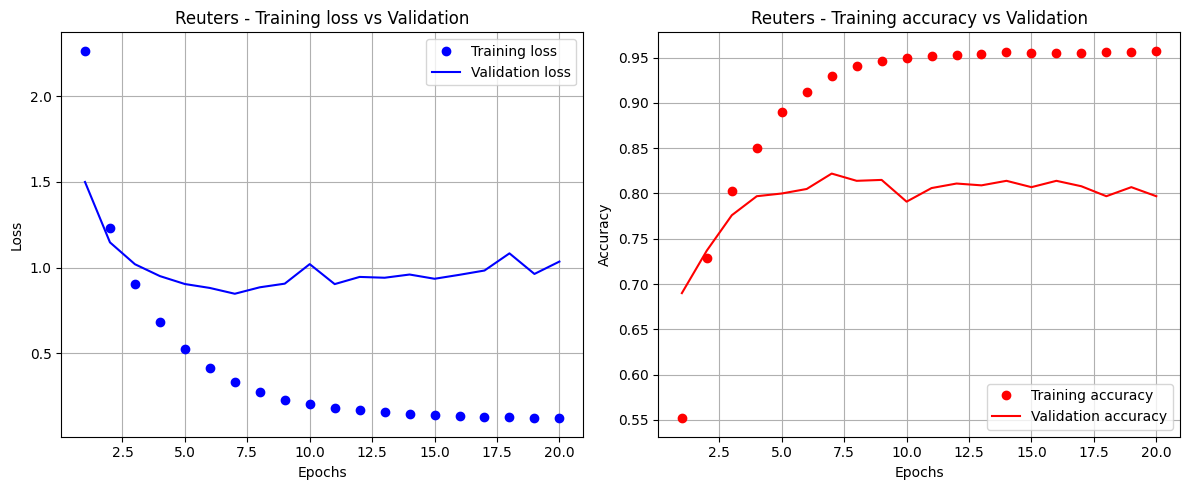

In [ ]:
import matplotlib.pyplot as plt

# Extract loss, val_loss, accuracy, val_accuracy from history.history
history_dict = history_reuters.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

# Draw the Loss plot
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(epochs, loss, 'bo', label='Training loss')
ax[0].plot(epochs, val_loss, 'b', label='Validation loss')
ax[0].set_title('Reuters - Training loss vs Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(epochs, acc, 'ro', label='Training accuracy')
ax[1].plot(epochs, val_acc, 'r', label='Validation accuracy')
ax[1].set_title('Reuters - Training accuracy vs Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Predict probabilities for the first test sample
predictions = reuters_model.predict(x_test)

first_prediction = predictions[0]

print("Predicted probabilities:", first_prediction)
print("Sum of probabilities:", np.sum(first_prediction))
print("Predicted label:", np.argmax(first_prediction))
print("Actual label   :", np.argmax(y_test[0]))

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Predicted probabilities: [1.51527945e-06 1.23616374e-07 1.94741062e-07 9.42407668e-01
 5.69067784e-02 1.70681058e-09 4.99595316e-08 1.04956337e-06
 2.04691445e-04 2.06202238e-08 1.03318894e-06 1.21770885e-04
 3.81964540e-08 4.07142943e-05 7.92734944e-09 5.47998180e-09
 7.65922086e-05 6.57054899e-09 1.87578621e-07 1.97901295e-06
 1.15870360e-04 5.84597547e-05 3.87419229e-11 3.01934278e-07
 5.49568213e-09 5.31178799e-08 1.09388756e-08 2.90271829e-09
 1.85023585e-09 4.17350338e-06 2.38056600e-06 2.91111007e-07
 2.94626943e-06 9.74592962e-10 3.10485063e-07 5.70166605e-07
 1.96374804e-05 1.61470326e-09 7.58828911e-09 2.82227938e-05
 7.65435271e-10 2.16072340e-06 2.38623774e-11 3.76206089e-09
 4.43833026e-10 1.24018837e-10]
Sum of probabilities: 0.9999999
Predicted label: 3
Actual label   : 3


### Neural Networks for Regression & Boston Housing Dataset

A Neural Network for Regression is used to predict continuous numerical values rather than discrete classes (e.g., predicting house prices). The model structure is similar to classification networks, but the output layer typically has no activation function (or a linear activation) to produce unrestricted numeric outputs. It is commonly trained using loss functions such as mean squared error (MSE), which measures the difference between predicted and actual values.

The Boston Housing Dataset is a classic benchmark for regression tasks. It contains information about housing in Boston suburbs, including features such as crime rate, number of rooms, and accessibility to highways. The target variable is the median house price, which the neural network aims to predict based on the input features.

When applied to this dataset, neural networks learn relationships between numerical and categorical features to estimate housing prices. This task demonstrates key concepts such as feature scaling (important for regression), model evaluation using metrics like MSE or MAE, and handling small datasets with techniques like validation splits to prevent overfitting.

In [7]:
from tensorflow.keras.datasets import boston_housing

# Load the boston housing dataset
(x_train, y_train), (x_test, y_test) = boston_housing.load_data()

# Display shape
print('Training set shape:', x_train.shape)
print('Testing set shape:', y_train.shape)
print('Train targets shape:', x_test.shape)
print('5 first target  :', y_test[:5])

Training set shape: (404, 13)
Testing set shape: (404,)
Train targets shape: (102, 13)
5 first target  : [ 7.2 18.8 19.  27.  22.2]


In [6]:
# Find mean and standard deviation
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)

# Normalize the data
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

# Print the mean and std of the normalized data

print('Mean:', x_train.mean())
print('Std :', x_train.std())

Mean: 1.0146745084159847e-17
Std : 1.0000000000000002


In [9]:
from tensorflow import keras
from tensorflow.keras import layers

# Build the model

def build_model():
  hidden_layer1 = layers.Dense(64, activation='relu')
  hidden_layer2 = layers.Dense(64, activation='relu')
  output_layer = layers.Dense(1)

  model = keras.Sequential([hidden_layer1, hidden_layer2, output_layer])
  model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
  return model

# Create a model
model = build_model()

In [13]:
# Training the Model (50 Epochs, Batch Size 16)
history = model.fit(x_train, y_train, epochs=50, batch_size=16,
                    validation_split=0.2, verbose=1)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 32.9351 - mae: 4.2237 - val_loss: 37.4730 - val_mae: 4.0954
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 28.7887 - mae: 4.0357 - val_loss: 79.8929 - val_mae: 6.8290
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29.9600 - mae: 3.9476 - val_loss: 105.6962 - val_mae: 9.4649
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 37.5681 - mae: 4.5421 - val_loss: 41.6230 - val_mae: 4.1395
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 29.1182 - mae: 4.0110 - val_loss: 61.5678 - val_mae: 6.8257
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 32.1269 - mae: 4.1041 - val_loss: 51.1439 - val_mae: 4.8479
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 32.1363 - mae: 4.1660 - val_loss: 36.3572 - val_mae: 4.4059
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28.3796 - mae: 3.8383 - val_loss: 34.8584 - val_mae: 4.1638
Epoch 9/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - los

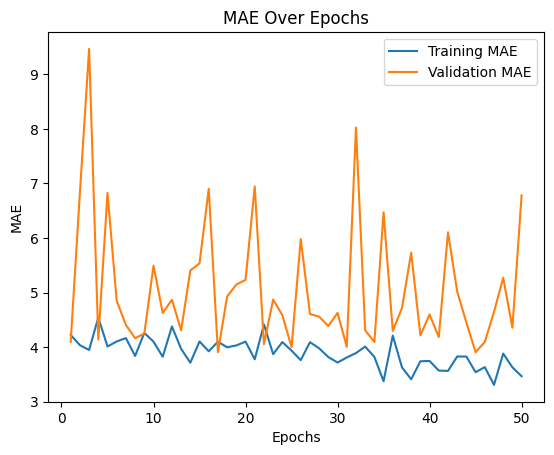

In [14]:
# Extract MAE Across Epochs
import matplotlib.pyplot as plt

mae = history.history['mae']
val_mae = history.history['val_mae']

epochs = range(1, len(mae) + 1)

plt.plot(epochs, mae, label='Training MAE')
plt.plot(epochs, val_mae, label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.title('MAE Over Epochs')
plt.show()

In [17]:
import numpy as np

# Mean MAE Calculation
mean_mae = np.mean(mae)
print("Mean Training MAE:", mean_mae)
# Mean MAE Calculation for validation
mean_val_mae = np.mean(val_mae)
print("Mean Validation MAE:", mean_val_mae)

Mean Training MAE: 3.8943840885162353
Mean Validation MAE: 5.065217866897583
